In [122]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

In [123]:
df = pd.read_csv(r"C:\Users\koolr\Downloads\archive (3)\results.csv")
df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'] >= '2010-01-01') & (df['date'] < '2026-06-11')].sort_values('date').reset_index(drop=True)

print(df.shape)

(15817, 9)


In [124]:
from collections import defaultdict

elo= defaultdict(lambda:1500)

def expected(ra, rb):
    return 1/ (1+10**((rb-ra)/400))


def update_elo(ra, rb, result, k=30):
    e= expected(ra, rb)
    new_ra= ra + k*(result-e)
    new_rb= rb + k*((1-result)-(1-e))

    return new_ra, new_rb

In [125]:
rows = []

for _, row in df.iterrows():
    h, a = row['home_team'], row['away_team']
    
    # Capture features BEFORE updating ELO
    feat = {
        'home_elo': elo[h],
        'away_elo': elo[a],
        'elo_diff': elo[h] - elo[a],
    }
    
    # Label
    if row['home_score'] > row['away_score']:
        feat['result'] = 2
    elif row['home_score'] == row['away_score']:
        feat['result'] = 1
    else:
        feat['result'] = 0
    
    rows.append(feat)
    
    # Update ELO AFTER capturing features
    result_val = 1 if feat['result'] == 2 else (0.5 if feat['result'] == 1 else 0)
    elo[h], elo[a] = update_elo(elo[h], elo[a], result_val)

features_df = pd.DataFrame(rows)
print(features_df.shape)
print(features_df.head())

(15817, 4)
   home_elo  away_elo  elo_diff  result
0    1500.0    1500.0       0.0       2
1    1500.0    1500.0       0.0       1
2    1500.0    1500.0       0.0       2
3    1500.0    1500.0       0.0       0
4    1500.0    1500.0       0.0       1


In [126]:
print(features_df.iloc[5000])

home_elo    1623.534744
away_elo    1316.828064
elo_diff     306.706680
result         2.000000
Name: 5000, dtype: float64


In [127]:
import os
os.makedirs("data", exist_ok=True)
features_df.to_csv("data/features.csv", index=False)
print("Features saved!")

Features saved!


In [128]:
x= features_df.drop("result", axis=1)
y = features_df["result"]
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, shuffle=False)

rf= RandomForestClassifier(n_estimators=200, random_state= 42)
rf.fit(x_train, y_train)

print(f"Accuracy: {accuracy_score(y_test, rf.predict(x_test)):.3f}")
print(f"Log Loss: {log_loss(y_test, rf.predict_proba(x_test)):.3f}")

Accuracy: 0.544
Log Loss: 1.303


In [129]:
import pickle


with open ("data/rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)
print("Model saved!")

Model saved!


In [130]:
def rf_match_probs(home,away):
    ra= elo.get(home, 1500)
    rb= elo.get(away,1500)

    feats = pd.DataFrame([[ra, rb, ra - rb]], columns=['home_elo', 'away_elo', 'elo_diff'])
    proba= rf.predict_proba(feats)[0]

    win =proba[2]
    draw = proba[1]
    loss = proba[0]

    return win, draw, loss

In [131]:
print(rf_match_probs("Brazil", "Honduras"))

win, draw, loss = rf_match_probs("Brazil", "Honduras")
print(f"Win: {win:.1%}")
print(f"Draw: {draw:.1%}")
print(f"Loss: {loss:.1%}")

(np.float64(0.88), np.float64(0.035), np.float64(0.085))
Win: 88.0%
Draw: 3.5%
Loss: 8.5%


In [132]:
def rf_match_probs(home, away):
    ra= elo.get(home, 1500)
    rb= elo.get(away, 1500)

    feats= [[ra, rb, ra-rb]]

    proba = rf.predict_proba(feats)[0]

    win = proba[2]
    draw= proba[1]
    loss= proba[0]

    return win, draw, loss

In [133]:
def simulate_match_v2(home, away, prob_fn):
    win, draw, loss = prob_fn(home, away)
    outcome= np.random.choice(["W", "D", "L"], p=[win, draw, loss])
    return outcome

In [134]:
def simulate_group_v2(group_letter, prob_fn):
    teams = groups[group_letter]
    points= defaultdict(int)

    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            home = teams[i]
            away= teams[j]
            outcome= simulate_match_v2(home, away, prob_fn)

            if outcome == "W":
                points[home] +=3
            elif outcome == "L":
                points[away] +=3
            else:
                points[home] +=1
                points[away] +=1
    standings= sorted(teams, key=lambda t: points[t], reverse= True)
    return standings

In [135]:
def simulate_group_stage_v2(prob_fn):
    qualifiers = []
    third_place = []

    for group_letter in groups:
        standings= simulate_group_v2(group_letter, prob_fn)
        qualifiers.append(standings[0])
        qualifiers.append(standings[1])
        third_place.append(standings[2])

    third_place= sorted(third_place, key=lambda t:elo.get(t, 1500), reverse= True)[:8]
    qualifiers.extend(third_place)
    return qualifiers

In [136]:
def simulate_knockout_v2(qualifiers, prob_fn):
    teams = qualifiers[:]

    while len(teams)>1:
        next_round = []
        for i in range(0, len(teams), 2):
            home= teams[i]
            away= teams[i+1]
            outcome = simulate_match_v2(home, away, prob_fn)
            if outcome == "D":
                outcome = np.random.choice(["w", "L"])
            if outcome =="W":
                next_round.append(home)
            else:
                next_round.append(away)
        teams= next_round
    
    return teams [0]
    

In [137]:
def run_monte_carlo_v2(prob_fn, n=10000):
    win_counts =Counter()

    for i in range(n):
        qualifiers= simulate_group_stage_v2(prob_fn)
        winner= simulate_knockout_v2(qualifiers, prob_fn)
        win_counts[winner] += 1
    
    results = {team: count/n for team, count in win_counts.most_common()}

    return results


In [138]:
def match_probabilities(home, away):
    ra= elo.get(home, 1500)
    rb= elo.get(away, 1500)
    e= 1/ (1+10**((rb-ra)/400))
    draw=0.25
    win= e*(1-draw)
    loss= (1-e)*(1-draw)
    return win, draw, loss

In [139]:
from collections import Counter

In [140]:
elo_results = run_monte_carlo_v2(match_probabilities, n=1000)

for team, prob in list(elo_results.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

Spain                14.6%
Argentina            9.4%
England              5.7%
Portugal             5.6%
France               4.8%
Morocco              4.0%
Croatia              3.7%
Colombia             3.3%
Brazil               3.0%
Japan                2.9%


In [141]:
import warnings
warnings.filterwarnings('ignore')

In [142]:
import warnings
warnings.filterwarnings('ignore')


all_teams = [team for group in groups.values() for team in group]


prob_cache = {}
for home in all_teams:
    for away in all_teams:
        if home != away:
            prob_cache[(home, away)] = rf_match_probs(home, away)

print(f"Cached {len(prob_cache)} matchups")


def rf_fast(home, away):
    return prob_cache[(home, away)]

Cached 2256 matchups


In [143]:
rf_results = run_monte_carlo_v2(rf_fast, n=1000)

for team, prob in list(rf_results.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

England              13.3%
Spain                11.4%
Colombia             8.5%
Argentina            8.4%
Netherlands          5.7%
Morocco              4.6%
Portugal             4.5%
Japan                4.4%
Ivory Coast          3.5%
Croatia              3.3%


In [144]:
print(f"France:      {elo['France']:.1f}")
print(f"Netherlands: {elo['Netherlands']:.1f}")
print(f"Colombia:    {elo['Colombia']:.1f}")
print(f"Spain:       {elo['Spain']:.1f}")
print(f"Argentina:   {elo['Argentina']:.1f}")

France:      1890.6
Netherlands: 1823.8
Colombia:    1847.5
Spain:       1948.7
Argentina:   1955.6


In [145]:
elo_results = run_monte_carlo_v2(match_probabilities, n=5000)
rf_results = run_monte_carlo_v2(rf_fast, n=5000)

print("=== ELO MODEL ===")
for team, prob in list(elo_results.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

print("\n=== RF MODEL ===")
for team, prob in list(rf_results.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

=== ELO MODEL ===
Spain                14.1%
Argentina            10.1%
England              6.3%
Japan                4.4%
Portugal             4.1%
Morocco              3.7%
Colombia             3.6%
Brazil               3.2%
France               3.2%
Croatia              3.1%

=== RF MODEL ===
Spain                13.1%
England              12.1%
Argentina            8.1%
Colombia             7.9%
Netherlands          5.9%
Morocco              5.1%
Portugal             4.9%
Japan                4.3%
Ivory Coast          3.1%
Iran                 2.8%


In [146]:
print("France's group:", [g for g, teams in groups.items() if "France" in teams])
print("France's group teams:", [teams for g, teams in groups.items() if "France" in teams][0])

france_group = [teams for g, teams in groups.items() if "France" in teams][0]
for opponent in france_group:
    if opponent != "France":
        win, draw, loss = match_probabilities("France", opponent)
        print(f"France vs {opponent}: Win {win:.1%} Draw {draw:.1%} Loss {loss:.1%}")

France's group: ['I']
France's group teams: ['France', 'Senegal', 'Norway', 'Iraq']
France vs Senegal: Win 47.9% Draw 25.0% Loss 27.1%
France vs Norway: Win 52.0% Draw 25.0% Loss 23.0%
France vs Iraq: Win 57.2% Draw 25.0% Loss 17.8%


In [147]:
france_qualifies = 0
france_wins_group = 0

for _ in range(1000):
    standings = simulate_group_v2("I", match_probabilities)
    if "France" in standings[:2]:
        france_qualifies += 1
    if standings[0] == "France":
        france_wins_group += 1

print(f"France qualifies from group: {france_qualifies/10:.1f}%")
print(f"France wins group: {france_wins_group/10:.1f}%")

France qualifies from group: 77.7%
France wins group: 51.6%


In [148]:
print(elo['France'])
print(elo['Brazil'])
print(elo['Germany'])
print(elo['England'])

1890.5659511723745
1865.5196767814966
1846.9364481328096
1853.2178110656773


In [149]:
def simulate_knockout_v2(qualifiers, prob_fn):
   
    group_winners = qualifiers[0::2][:12]  
    runners_up = qualifiers[1::2][:12]       
    third_place = qualifiers[24:]           

   
    round_of_32 = []
    for i in range(12):
        round_of_32.append(group_winners[i])
        round_of_32.append(runners_up[i])
    round_of_32.extend(third_place[:8] if len(third_place) >= 8 else third_place)

    teams = round_of_32

    while len(teams) > 1:
        next_round = []
        for i in range(0, len(teams) - 1, 2):
            home = teams[i]
            away = teams[i+1]
            outcome = simulate_match_v2(home, away, prob_fn)
            if outcome == 'D':
                outcome = np.random.choice(['W', 'L'])
            if outcome == 'W':
                next_round.append(home)
            else:
                next_round.append(away)
        teams = next_round

    return teams[0]

In [150]:
france_wins = 0
france_qualifies = 0

for _ in range(5000):
    qualifiers = simulate_group_stage_v2(match_probabilities)
    if "France" in qualifiers:
        france_qualifies += 1
        winner = simulate_knockout_v2(qualifiers, match_probabilities)
        if winner == "France":
            france_wins += 1

print(f"France qualifies: {france_qualifies/50:.1f}%")
print(f"France wins tournament (when qualified): {france_wins/france_qualifies*100:.1f}%")
print(f"France overall win probability: {france_wins/5000*100:.1f}%")

France qualifies: 92.6%
France wins tournament (when qualified): 6.2%
France overall win probability: 5.8%


In [151]:
elo_results = run_monte_carlo_v2(match_probabilities, n=5000)

print("=== ELO MODEL ===")
for team, prob in list(elo_results.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

=== ELO MODEL ===
Argentina            11.2%
Spain                10.9%
Morocco              5.6%
France               5.5%
Brazil               5.2%
Portugal             4.9%
Japan                4.2%
Germany              4.0%
England              3.9%
Mexico               3.7%


In [152]:
rf_results = run_monte_carlo_v2(rf_fast, n=5000)

print("=== RF MODEL ===")
for team, prob in list(rf_results.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

=== RF MODEL ===
Morocco              9.7%
France               6.4%
Spain                6.3%
Mexico               5.6%
Netherlands          5.5%
Portugal             5.2%
England              5.2%
Argentina            5.2%
Japan                4.9%
Colombia             4.6%


In [153]:
test_qualifiers = simulate_group_stage_v2(match_probabilities)
print(f"Total qualifiers: {len(test_qualifiers)}")
print(test_qualifiers)


Total qualifiers: 32
['Mexico', 'South Korea', 'Canada', 'Qatar', 'Scotland', 'Brazil', 'United States', 'Turkey', 'Germany', 'Ivory Coast', 'Japan', 'Netherlands', 'Iran', 'Egypt', 'Spain', 'Cape Verde', 'France', 'Norway', 'Argentina', 'Austria', 'Colombia', 'DR Congo', 'Ghana', 'England', 'Morocco', 'Ecuador', 'Croatia', 'Belgium', 'Uruguay', 'Switzerland', 'Uzbekistan', 'Paraguay']


In [154]:
print(f"Morocco ELO: {elo['Morocco']:.1f}")
print(f"Spain ELO:   {elo['Spain']:.1f}")
print(f"France ELO:  {elo['France']:.1f}")


print("\nMorocco vs Spain:", rf_fast("Morocco", "Spain"))
print("Morocco vs France:", rf_fast("Morocco", "France"))
print("Morocco vs Argentina:", rf_fast("Morocco", "Argentina"))

Morocco ELO: 1878.8
Spain ELO:   1948.7
France ELO:  1890.6

Morocco vs Spain: (np.float64(0.235), np.float64(0.625), np.float64(0.14))
Morocco vs France: (np.float64(0.325), np.float64(0.37), np.float64(0.305))
Morocco vs Argentina: (np.float64(0.275), np.float64(0.6), np.float64(0.125))


In [155]:
def rf_fast_fixed(home, away):
    win, draw, loss = prob_cache[(home, away)]
    draw = min(draw, 0.35)
    total = win + draw + loss
    return win/total, draw/total, loss/total

In [156]:
rf_results = run_monte_carlo_v2(rf_fast_fixed, n=5000)

print("=== RF MODEL (FIXED) ===")
for team, prob in list(rf_results.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

=== RF MODEL (FIXED) ===
Morocco              10.6%
Spain                6.3%
Netherlands          6.2%
Mexico               6.1%
Argentina            6.0%
France               6.0%
England              4.9%
Portugal             4.8%
Japan                4.7%
Brazil               4.6%


In [157]:
all_teams = set(elo_results.keys()) | set(rf_results.keys())

combined = {}
for team in all_teams:
    elo_prob = elo_results.get(team, 0)
    rf_prob = rf_results.get(team, 0)
    combined[team] = (elo_prob + rf_prob) / 2

combined = dict(sorted(combined.items(), key=lambda x: -x[1]))

print("=== COMBINED MODEL (ELO + RF AVERAGE) ===")
for team, prob in list(combined.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

=== COMBINED MODEL (ELO + RF AVERAGE) ===
Spain                8.6%
Argentina            8.6%
Morocco              8.1%
France               5.8%
Mexico               4.9%
Brazil               4.9%
Portugal             4.9%
Netherlands          4.6%
Japan                4.5%
England              4.4%


In [158]:
team_climate = {
    "Brazil":        {"temp": 28, "humidity": 80, "altitude": 75},
    "Argentina":     {"temp": 12, "humidity": 70, "altitude": 25},
    "France":        {"temp": 20, "humidity": 65, "altitude": 96},
    "Germany":       {"temp": 19, "humidity": 63, "altitude": 51},
    "England":       {"temp": 18, "humidity": 72, "altitude": 11},
    "Spain":         {"temp": 30, "humidity": 40, "altitude": 667},
    "Portugal":      {"temp": 28, "humidity": 55, "altitude": 92},
    "Netherlands":   {"temp": 18, "humidity": 75, "altitude": 2},
    "Mexico":        {"temp": 26, "humidity": 50, "altitude": 2250},
    "United States": {"temp": 25, "humidity": 60, "altitude": 202},
    "Colombia":      {"temp": 24, "humidity": 78, "altitude": 2600},
    "Ecuador":       {"temp": 22, "humidity": 76, "altitude": 2850},
    "Honduras":      {"temp": 30, "humidity": 82, "altitude": 994},
    "Costa Rica":    {"temp": 27, "humidity": 80, "altitude": 1161},
    "Senegal":       {"temp": 30, "humidity": 74, "altitude": 24},
    "Nigeria":       {"temp": 32, "humidity": 78, "altitude": 342},
    "Morocco":       {"temp": 28, "humidity": 58, "altitude": 545},
    "Japan":         {"temp": 27, "humidity": 74, "altitude": 40},
    "South Korea":   {"temp": 24, "humidity": 70, "altitude": 38},
    "Canada":        {"temp": 14, "humidity": 58, "altitude": 116},
    "Croatia":       {"temp": 25, "humidity": 55, "altitude": 158},
    "Belgium":       {"temp": 17, "humidity": 76, "altitude": 58},
    "Austria":       {"temp": 19, "humidity": 65, "altitude": 171},
    "Switzerland":   {"temp": 18, "humidity": 67, "altitude": 540},
    "Uruguay":       {"temp": 13, "humidity": 74, "altitude": 43},
    "Algeria":       {"temp": 28, "humidity": 42, "altitude": 424},
    "Norway":        {"temp": 15, "humidity": 70, "altitude": 23},
    "Iraq":          {"temp": 40, "humidity": 25, "altitude": 34},
    "Turkey":        {"temp": 26, "humidity": 55, "altitude": 894},
    "Paraguay":      {"temp": 18, "humidity": 72, "altitude": 101},
    "Australia":     {"temp": 12, "humidity": 55, "altitude": 600},
    "Saudi Arabia":  {"temp": 38, "humidity": 30, "altitude": 612},
    "Iran":          {"temp": 30, "humidity": 35, "altitude": 1191},
    "Egypt":         {"temp": 35, "humidity": 40, "altitude": 23},
    "Ghana":         {"temp": 30, "humidity": 77, "altitude": 61},
    "Panama":        {"temp": 30, "humidity": 82, "altitude": 55},
    "Tunisia":       {"temp": 30, "humidity": 55, "altitude": 4},
    "Ivory Coast":   {"temp": 27, "humidity": 80, "altitude": 226},
    "Curacao":       {"temp": 29, "humidity": 76, "altitude": 10},
    "Haiti":         {"temp": 29, "humidity": 79, "altitude": 72},
    "Scotland":      {"temp": 14, "humidity": 78, "altitude": 52},
    "Bolivia":       {"temp": 8,  "humidity": 45, "altitude": 3640},
    "New Zealand":   {"temp": 12, "humidity": 70, "altitude": 196},
    "DR Congo":      {"temp": 25, "humidity": 82, "altitude": 310},
    "Uzbekistan":    {"temp": 25, "humidity": 40, "altitude": 455},
    "Bosnia and Herzegovina": {"temp": 18, "humidity": 65, "altitude": 511},
    "Cape Verde":    {"temp": 26, "humidity": 70, "altitude": 212},
}

host_climate = {
    "Miami":         {"temp": 32, "humidity": 80, "altitude": 2},
    "Houston":       {"temp": 34, "humidity": 75, "altitude": 15},
    "Dallas":        {"temp": 35, "humidity": 55, "altitude": 139},
    "Los Angeles":   {"temp": 25, "humidity": 60, "altitude": 71},
    "San Francisco": {"temp": 17, "humidity": 75, "altitude": 16},
    "Seattle":       {"temp": 18, "humidity": 70, "altitude": 56},
    "New York":      {"temp": 27, "humidity": 65, "altitude": 10},
    "Boston":        {"temp": 24, "humidity": 66, "altitude": 14},
    "Philadelphia":  {"temp": 28, "humidity": 65, "altitude": 12},
    "Kansas City":   {"temp": 30, "humidity": 68, "altitude": 265},
    "Atlanta":       {"temp": 31, "humidity": 72, "altitude": 320},
    "Guadalajara":   {"temp": 24, "humidity": 55, "altitude": 1566},
    "Mexico City":   {"temp": 21, "humidity": 45, "altitude": 2250},
    "Monterrey":     {"temp": 34, "humidity": 55, "altitude": 538},
    "Toronto":       {"temp": 22, "humidity": 65, "altitude": 76},
    "Vancouver":     {"temp": 18, "humidity": 70, "altitude": 70},
}

def climate_similarity(team, city):
    if team not in team_climate or city not in host_climate:
        return 0.5
    t = team_climate[team]
    c = host_climate[city]
    temp_diff     = abs(t["temp"]     - c["temp"])     / 30
    humidity_diff = abs(t["humidity"] - c["humidity"]) / 80
    altitude_diff = abs(t["altitude"] - c["altitude"]) / 3000
    weighted_diff = (0.45 * temp_diff + 0.40 * humidity_diff + 0.15 * altitude_diff)
    return round(max(0, 1 - weighted_diff), 4)

In [159]:
def match_probabilities_climate(home, away, city= "Dallas"):
    ra= elo.get(home, 1500)
    rb= elo.get(away, 1500)
    e= 1/ (1+10**((rb-ra)/400))

    home_cs= climate_similarity(home,city)
    away_cs= climate_similarity(away, city)
    climate_edge = (home_cs-away_cs)*0.05
    e= min(max(e+climate_edge, 0.05), 0.95)

    draw= 0.25
    win = e*(1-draw)
    loss = (1-e) * (1-draw)
    return win, draw, loss



In [160]:
print(match_probabilities_climate("Brazil", "Germany", "Miami"))
print(match_probabilities_climate("Brazil", "Germany", "Vancouver"))

(0.4032472065399979, 0.25, 0.3467527934600021)
(0.3894397065399979, 0.25, 0.3605602934600021)


In [161]:
climate_results= run_monte_carlo_v2(match_probabilities_climate, n=5000)

print("ELO+Climate_Model")
for team, prob in list(climate_results.items())[:10]:
    print (f"{team:<20} {prob:.1%}")




ELO+Climate_Model
Spain                12.1%
Argentina            10.0%
Morocco              6.7%
France               5.7%
Brazil               5.0%
Japan                4.7%
Portugal             4.5%
England              4.2%
Mexico               3.5%
Germany              3.4%


In [162]:
all_teams = set(elo_results.keys()) | set(rf_results.keys()) | set(climate_results.keys())

final_combined= {}
for team in all_teams:
    elo_prob = elo_results.get(team, 0)
    rf_prob= rf_results.get(team, 0)
    climate_prob= climate_results.get(team, 0)
    final_combined[team] = (elo_prob + rf_prob + climate_prob) / 3
    
final_combined= dict(sorted(final_combined.items(), key= lambda x: -x[1]))

print("FINAL COMBINED MODEL(ELO+RF+CLIMATE)")
for team, prob in list(final_combined.items())[:10]:
    print(f"{team:<20} {prob:.1%}")


FINAL COMBINED MODEL(ELO+RF+CLIMATE)
Spain                9.8%
Argentina            9.1%
Morocco              7.7%
France               5.7%
Brazil               4.9%
Portugal             4.7%
Japan                4.6%
Mexico               4.4%
England              4.3%
Netherlands          4.0%


In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [164]:
x= features_df.drop("result", axis=1)
y= features_df["result"]    


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle= False)

scaler= StandardScaler()

x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)


lr= LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train_scaled, y_train)

print(f"Accuracy: {accuracy_score(y_test, lr.predict(x_test_scaled)):.3f}")
print(f"Log Loss: {log_loss(y_test, lr.predict_proba(x_test_scaled)):.3f}")

Accuracy: 0.591
Log Loss: 0.887


In [165]:
def lr_match_probs(home, away):
    ra= elo.get(home, 1500)
    rb= elo.get(away, 1500)


    feats= scaler.transform([[ra, rb, ra-rb]])
    proba= lr.predict_proba(feats)[0]

    win = proba[2]
    draw= proba[1]
    loss= proba[0]

    return win, draw, loss

In [166]:
print(lr_match_probs("Brazil", "Honduras"))

(np.float64(0.8117649312100185), np.float64(0.15317824270470617), np.float64(0.035056826085275314))


In [167]:
lr_prob_cache = {}

for home in all_teams:
    for away in all_teams:
        if home != away:
            lr_prob_cache[(home, away)] = lr_match_probs(home, away)

def lr_fast(home, away):
    return lr_prob_cache.get((home, away), lr_match_probs(home, away))

print(f"Cached {len(lr_prob_cache)} matchups")

Cached 2070 matchups


In [168]:
lr_results = run_monte_carlo_v2(lr_fast, n=5000)

print("=== LOGISTIC REGRESSION MODEL ===")
for team, prob in list(lr_results.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

=== LOGISTIC REGRESSION MODEL ===
Argentina            16.7%
Spain                15.1%
France               8.0%
Morocco              7.6%
Brazil               6.6%
Japan                5.0%
Mexico               4.7%
Portugal             4.6%
Germany              4.3%
England              3.3%


In [169]:
all_teams = set(elo_results.keys()) | set(rf_results.keys()) | set(climate_results.keys()) | set(lr_results.keys())

final_combined = {}
for team in all_teams:
    elo_prob     = elo_results.get(team, 0)
    rf_prob      = rf_results.get(team, 0)
    climate_prob = climate_results.get(team, 0)
    lr_prob      = lr_results.get(team, 0)
    final_combined[team] = (elo_prob + rf_prob + climate_prob + lr_prob) / 4

final_combined = dict(sorted(final_combined.items(), key=lambda x: -x[1]))

print("=== FINAL COMBINED MODEL (ELO + RF + CLIMATE + LR) ===")
for team, prob in list(final_combined.items())[:10]:
    print(f"{team:<20} {prob:.1%}")

=== FINAL COMBINED MODEL (ELO + RF + CLIMATE + LR) ===
Spain                11.1%
Argentina            11.0%
Morocco              7.7%
France               6.3%
Brazil               5.3%
Portugal             4.7%
Japan                4.7%
Mexico               4.5%
England              4.1%
Netherlands          3.6%


In [170]:
import matplotlib.pyplot as plt
import numpy as np

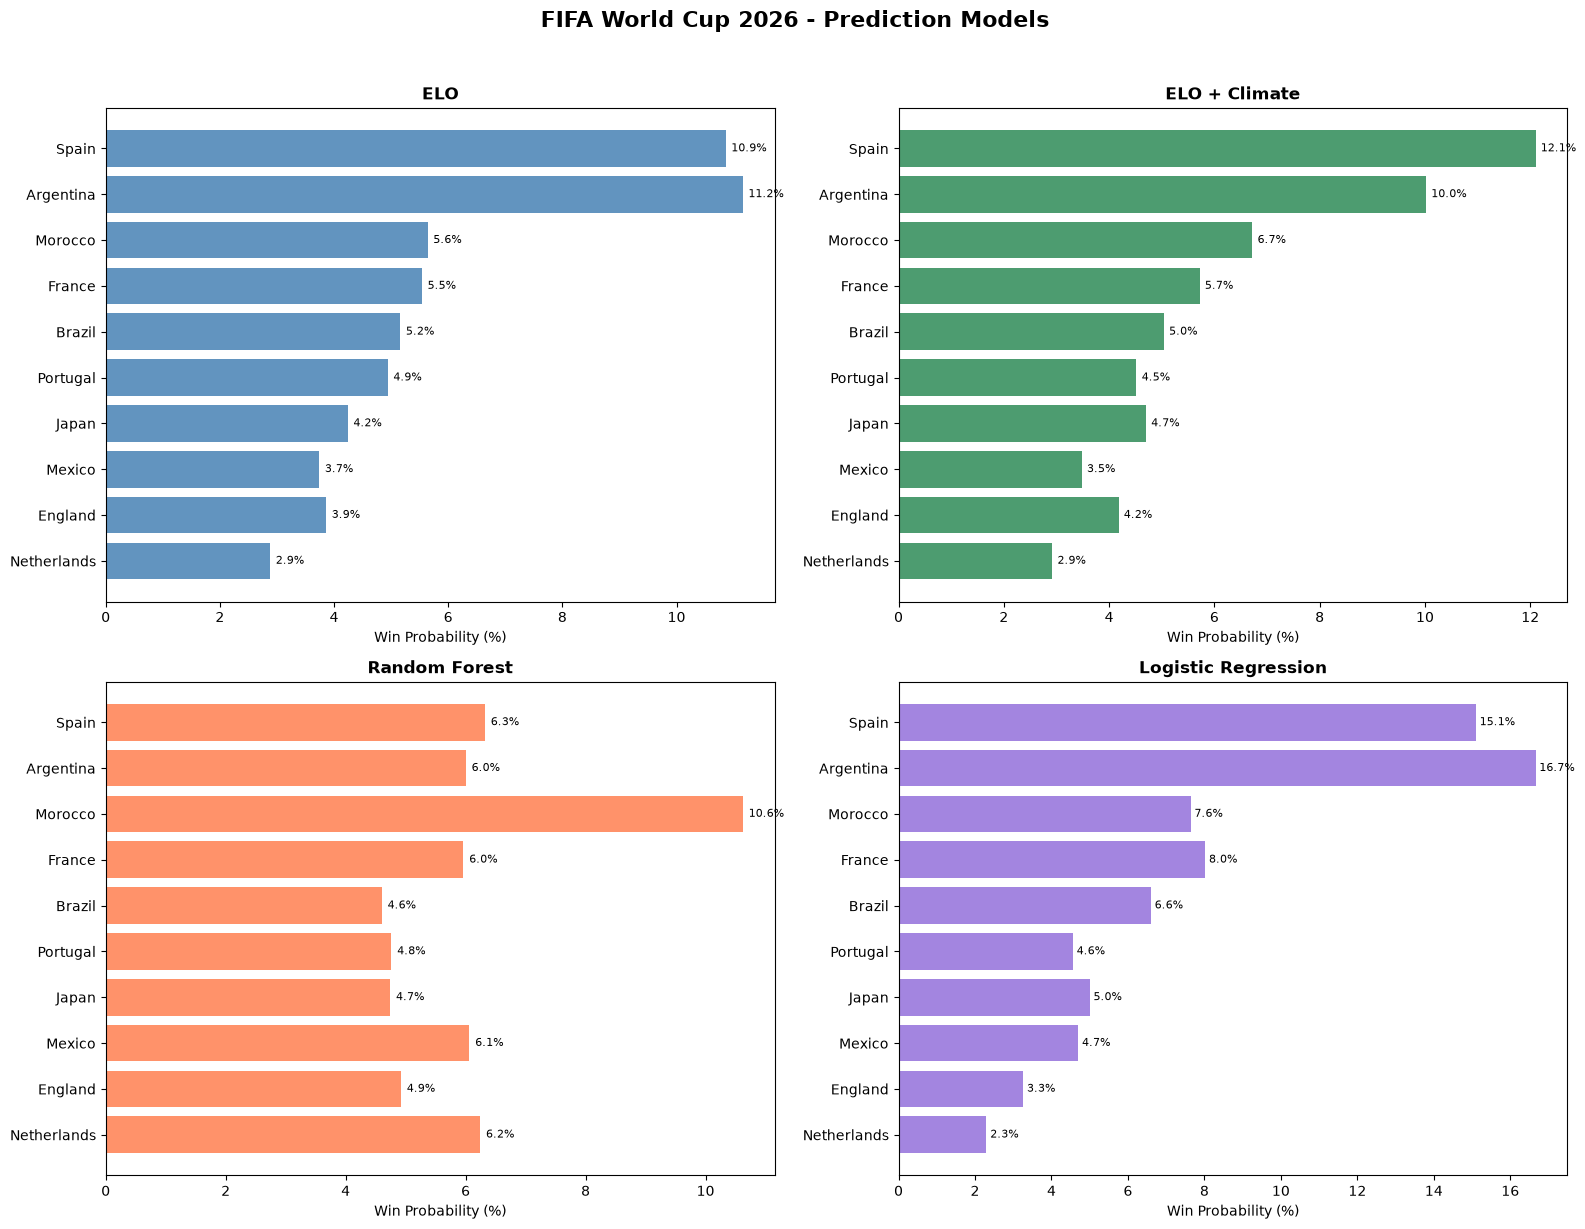

In [171]:


models= {
    "ELO": elo_results,
    "ELO + Climate":climate_results,
    "Random Forest": rf_results,
    "Logistic Regression": lr_results,
    "Combined": final_combined
}

top_teams= list(final_combined.keys())[:10]


colors= ["steelblue", "seagreen", "coral", "mediumpurple", "gold"]

fig, axes = plt.subplots(2,2, figsize=(16,12))
fig.suptitle("FIFA World Cup 2026 - Prediction Models", fontsize= 16, fontweight="bold", y=1.02)

model_names= ["ELO", "ELO + Climate", "Random Forest", "Logistic Regression"]

for idx, (ax, model_name) in enumerate(zip(axes.flat, model_names)):    
    probs = [models[model_name].get(t, 0)*100 for t in top_teams]
    bars= ax.barh(top_teams[::-1], probs[::-1], color=colors[idx], alpha=0.85)
    ax.set_xlabel("Win Probability (%)")
    ax.set_title(model_name, fontweight= "bold")
    for bar, prob in zip(bars, probs[::-1]):
        ax.text(bar.get_width() +0.1, bar.get_y() + bar.get_height()/2, f"{prob:.1f}%",va="center", fontsize=8)


plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches= "tight")
plt.show()


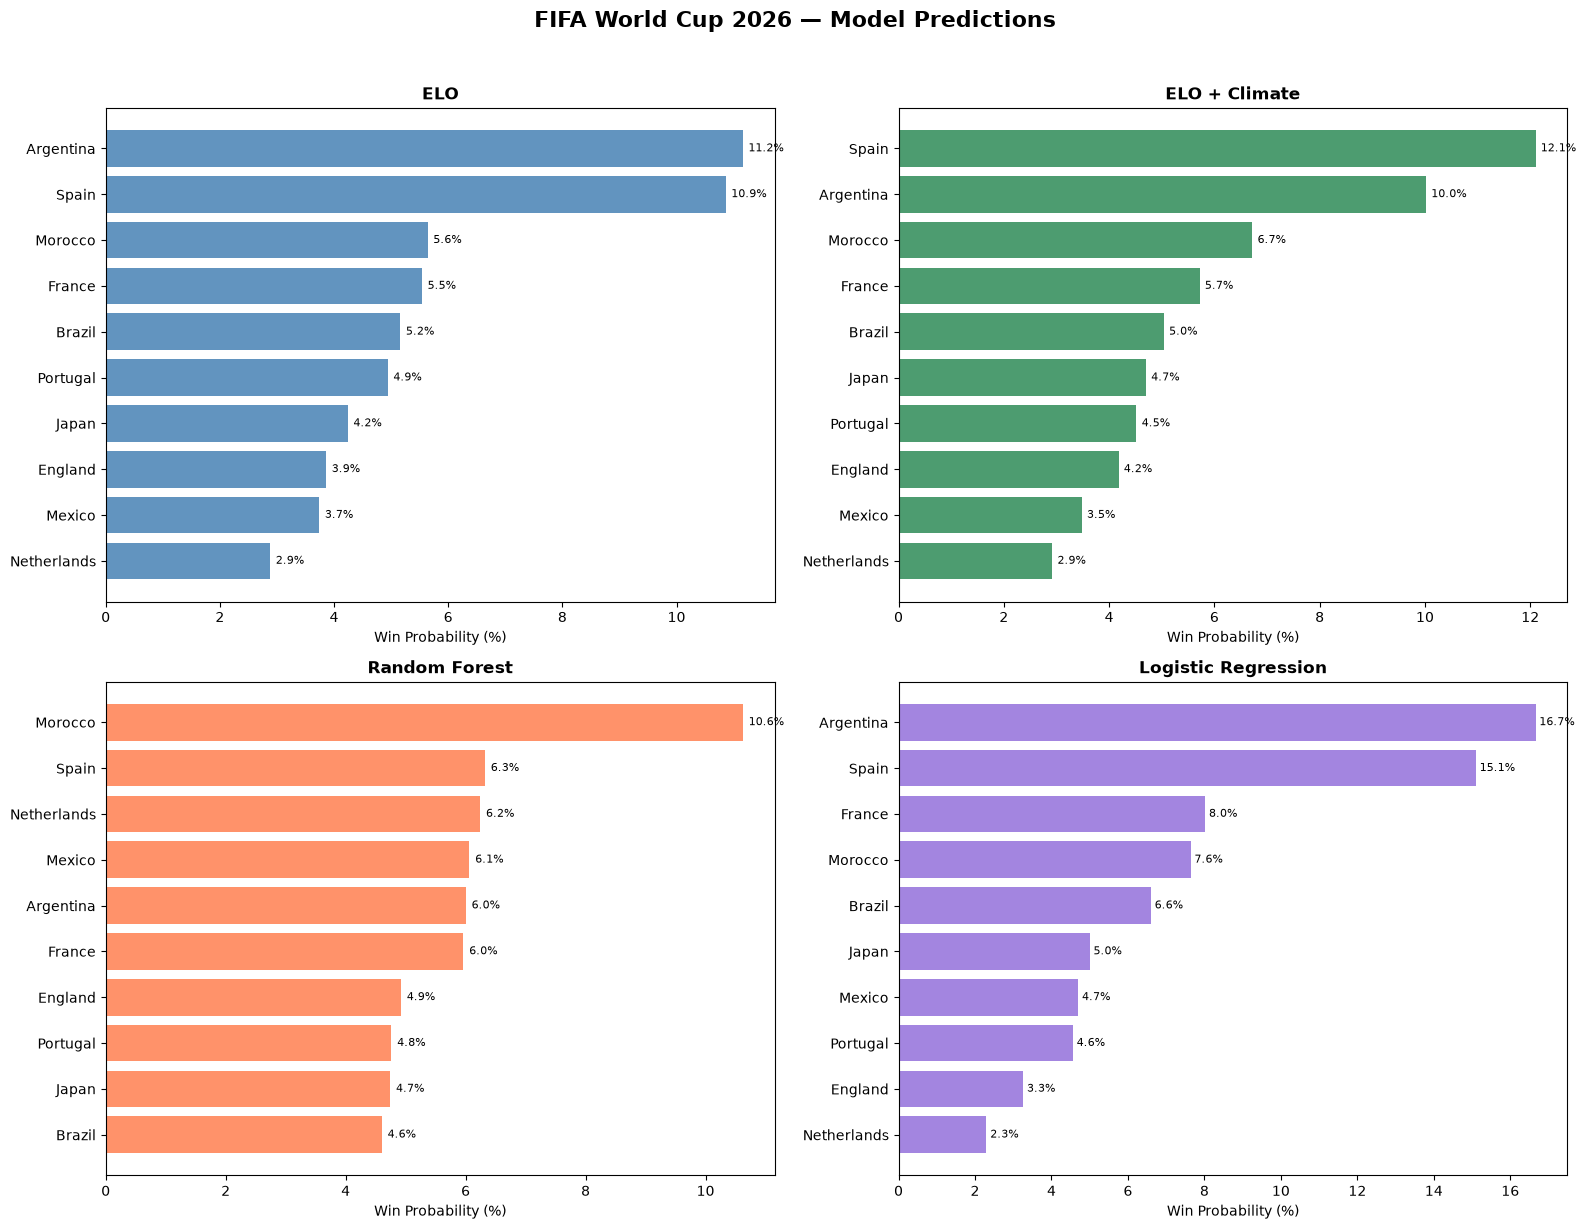

In [172]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('FIFA World Cup 2026 — Model Predictions', 
             fontsize=16, fontweight='bold', y=1.02)

model_names = ['ELO', 'ELO + Climate', 'Random Forest', 'Logistic Regression']
colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

for idx, (ax, model_name) in enumerate(zip(axes.flatten(), model_names)):
    
    model_data = models[model_name]
    sorted_teams = sorted(top_teams, key=lambda t: model_data.get(t, 0))
    probs = [model_data.get(t, 0) * 100 for t in sorted_teams]
    
    bars = ax.barh(sorted_teams, probs, color=colors[idx], alpha=0.85)
    ax.set_xlabel("Win Probability (%)")
    ax.set_title(model_name, fontweight='bold')
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{prob:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

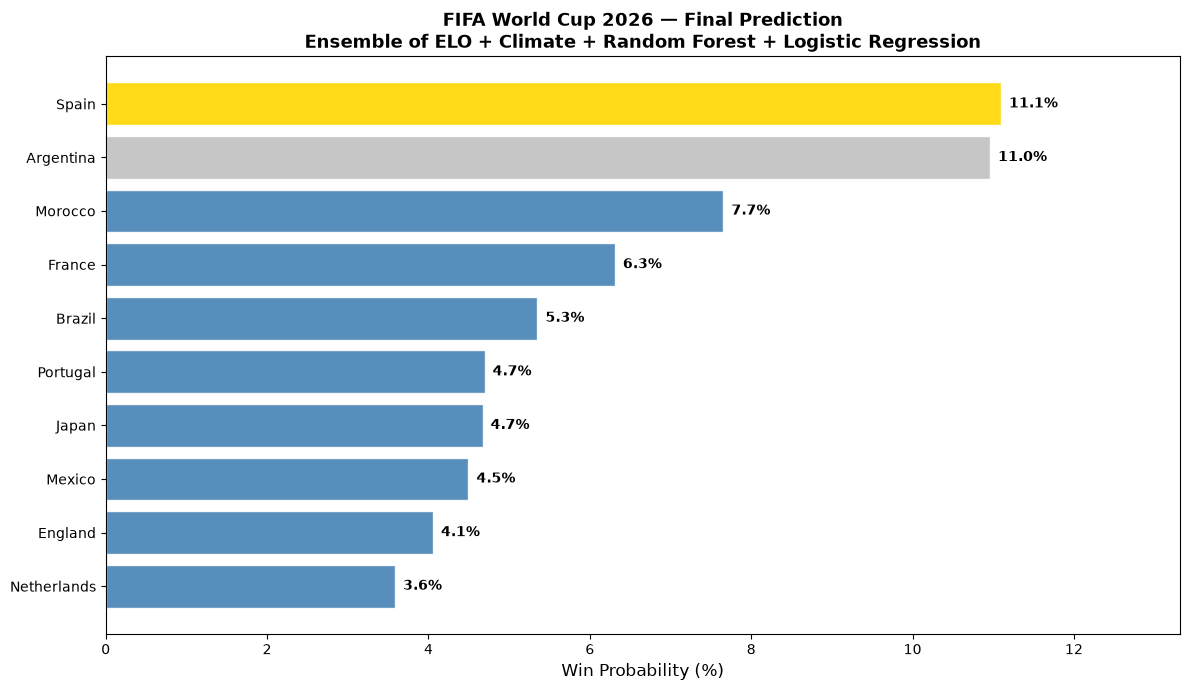

In [173]:
fig, ax = plt.subplots(figsize=(12, 7))

teams = list(final_combined.keys())[:10]
probs = [final_combined[t] * 100 for t in teams]
teams_sorted = sorted(zip(teams, probs), key=lambda x: x[1])
teams_plot = [t[0] for t in teams_sorted]
probs_plot = [t[1] for t in teams_sorted]

colors_bar = ['gold' if t == teams_plot[-1] else 
              'silver' if t == teams_plot[-2] else 
              'steelblue' for t in teams_plot]

bars = ax.barh(teams_plot, probs_plot, color=colors_bar, alpha=0.9, edgecolor='white')

ax.set_xlabel("Win Probability (%)", fontsize=12)
ax.set_title("FIFA World Cup 2026 — Final Prediction\nEnsemble of ELO + Climate + Random Forest + Logistic Regression",
             fontsize=13, fontweight='bold')

for bar, prob in zip(bars, probs_plot):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{prob:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, max(probs_plot) * 1.2)
plt.tight_layout()
plt.savefig("final_prediction.png", dpi=150, bbox_inches='tight')
plt.show()

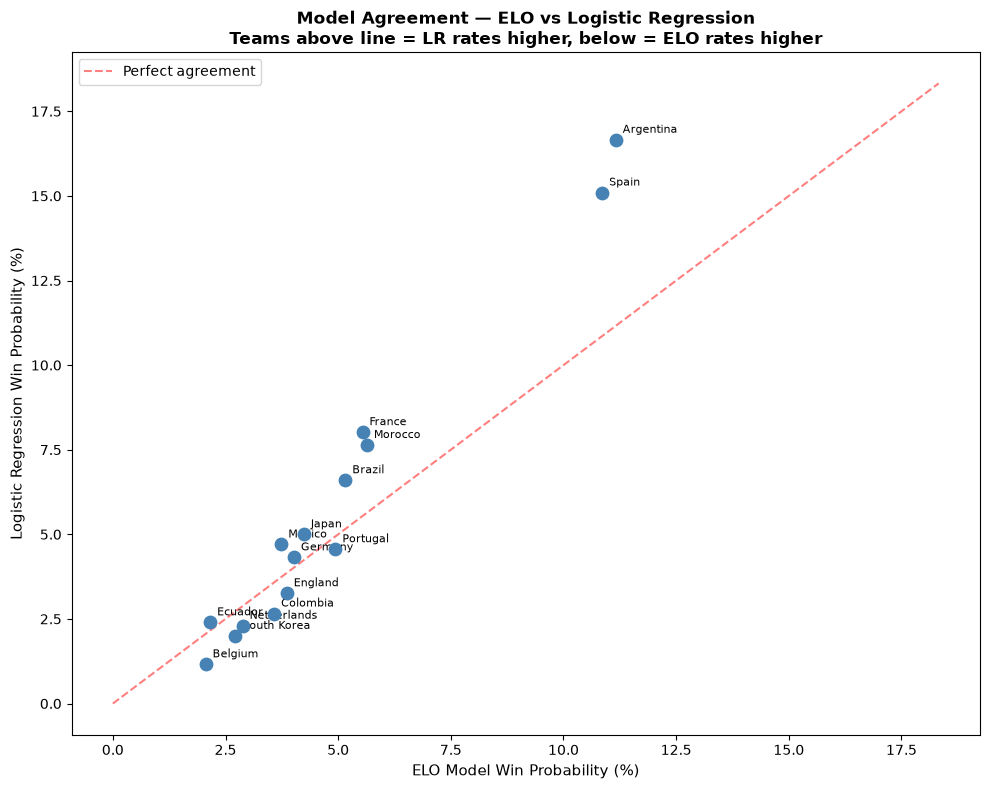

In [174]:
fig, ax = plt.subplots(figsize=(10, 8))

teams_to_plot = list(final_combined.keys())[:15]

elo_probs  = [elo_results.get(t, 0) * 100 for t in teams_to_plot]
lr_probs   = [lr_results.get(t, 0) * 100 for t in teams_to_plot]

ax.scatter(elo_probs, lr_probs, color='steelblue', s=80, zorder=5)


max_val = max(max(elo_probs), max(lr_probs)) * 1.1
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Perfect agreement')

# Label each dot with team name
for team, x, y in zip(teams_to_plot, elo_probs, lr_probs):
    ax.annotate(team, (x, y), 
                textcoords="offset points", 
                xytext=(5, 5),
                fontsize=8)

ax.set_xlabel("ELO Model Win Probability (%)", fontsize=11)
ax.set_ylabel("Logistic Regression Win Probability (%)", fontsize=11)
ax.set_title("Model Agreement — ELO vs Logistic Regression\nTeams above line = LR rates higher, below = ELO rates higher",
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("model_agreement.png", dpi=150, bbox_inches='tight')
plt.show()

In [175]:
import os
files = os.listdir(".")
charts = [f for f in files if f.endswith(".png")]
print(charts)

['final_prediction.png', 'model_agreement.png', 'model_comparison.png']


In [176]:
%whos DataFrame

Variable      Type         Data/Info
------------------------------------
df            DataFrame    Shape: (15817, 9)
features_df   DataFrame    Shape: (15817, 4)
x_test        DataFrame    Shape: (3164, 3)
x_train       DataFrame    Shape: (12653, 3)


In [177]:
%whos dict list

Variable          Type    Data/Info
-----------------------------------
cell              dict    n=6
charts            list    n=3
climate_results   dict    n=45
colors            list    n=4
colors_bar        list    n=10
combined          dict    n=46
elo_probs         list    n=15
elo_results       dict    n=46
feat              dict    n=4
files             list    n=16
final_combined    dict    n=46
france_group      list    n=4
groups            dict    n=12
host_climate      dict    n=16
lr_prob_cache     dict    n=2070
lr_probs          list    n=15
lr_results        dict    n=39
model_data        dict    n=39
model_names       list    n=4
models            dict    n=5
nb                dict    n=4
prob_cache        dict    n=2256
probs             list    n=10
probs_plot        list    n=10
qualifiers        list    n=32
rf_results        dict    n=39
rows              list    n=15817
sorted_teams      list    n=10
standings         list    n=4
team_climate      dict    n=47


In [178]:
import json, glob
for nb in glob.glob('*.ipynb'):
    text = open(nb, encoding='utf-8').read()
    print(nb, '→ final_prediction:', 'final_prediction' in text, '| monte carlo:', 'simulat' in text.lower())

FifaWC.ipynb → final_prediction: False | monte carlo: False
FIFAWC2.ipynb → final_prediction: False | monte carlo: True
FIFAWC3.ipynb → final_prediction: True | monte carlo: True


In [179]:
%whos

Variable                      Type                      Data/Info
-----------------------------------------------------------------
Counter                       type                      <class 'collections.Counter'>
LogisticRegression            type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier        ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler                type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
a                             str                       Pakistan
accuracy_score                function                  <function accuracy_score at 0x0000014962EB5590>
all_teams                     set                       {'Brazil', 'Paraguay', 'F<...>, 'South Korea', 'Ghana'}
away                          str                       Ghana
ax                            Axes                      Axes(0.0765556,0.0743056;0.908444x0.852767)
axe

In [180]:
import inspect
print(inspect.getsource(run_monte_carlo_v2))

def run_monte_carlo_v2(prob_fn, n=10000):
    win_counts =Counter()

    for i in range(n):
        qualifiers= simulate_group_stage_v2(prob_fn)
        winner= simulate_knockout_v2(qualifiers, prob_fn)
        win_counts[winner] += 1

    results = {team: count/n for team, count in win_counts.most_common()}

    return results



In [181]:
import os
print(os.path.exists('champ_probs.csv'))

True


In [182]:
import pandas as pd
print(pd.read_csv('champ_probs.csv').head(10))

         date             home_team    away_team  home_score  away_score  \
0  2010-01-02                  Iran  North Korea         1.0         0.0   
1  2010-01-02                 Qatar         Mali         0.0         0.0   
2  2010-01-02                 Syria     Zimbabwe         6.0         0.0   
3  2010-01-02                 Yemen   Tajikistan         0.0         1.0   
4  2010-01-03                Angola       Gambia         1.0         1.0   
5  2010-01-04                 Egypt         Mali         1.0         0.0   
6  2010-01-04              Tanzania  Ivory Coast         0.0         1.0   
7  2010-01-05                 Ghana       Malawi         0.0         0.0   
8  2010-01-06                 Yemen        Japan         2.0         3.0   
9  2010-01-06  United Arab Emirates     Malaysia         1.0         0.0   

                    tournament                        city  \
0                     Friendly                        Doha   
1                     Friendly         

In [186]:
import pandas as pd

found = None
for name, val in list(globals().items()):
    if isinstance(val, dict) and len(val) >= 10 and 'Spain' in val:
        try:
            if all(isinstance(v, float) for v in val.values()) and 0 < val['Spain'] < 1:
                print(f"Found it: variable is named '{name}' | Spain = {val['Spain']:.1%}")
                found = val
        except Exception:
            pass

if found:
    out = pd.DataFrame(found.items(), columns=['Team', 'Win_Prob'])
    out = out.sort_values('Win_Prob', ascending=False)
    out.to_csv('wc_predictions.csv', index=False)
    print(out.head(10))
else:
    print("No results dict in memory — the final-model cell needs to be re-run first.")

Found it: variable is named 'elo_results' | Spain = 10.9%
Found it: variable is named 'rf_results' | Spain = 6.3%
Found it: variable is named 'combined' | Spain = 8.6%
Found it: variable is named 'climate_results' | Spain = 12.1%
Found it: variable is named 'final_combined' | Spain = 11.1%
Found it: variable is named 'lr_results' | Spain = 15.1%
Found it: variable is named 'model_data' | Spain = 15.1%
        Team  Win_Prob
0  Argentina    0.1666
1      Spain    0.1510
2     France    0.0802
3    Morocco    0.0764
4     Brazil    0.0660
5      Japan    0.0500
6     Mexico    0.0470
7   Portugal    0.0456
8    Germany    0.0432
9    England    0.0326


In [187]:
import pandas as pd

# the headline file for Power BI
out = pd.DataFrame(final_combined.items(), columns=['Team', 'Win_Prob'])
out = out.sort_values('Win_Prob', ascending=False)
out.to_csv('wc_predictions.csv', index=False)

# bonus: all models side by side — great for a model-comparison dashboard page
models = {'ELO': elo_results, 'RF': rf_results, 'LR': lr_results,
          'Climate': climate_results, 'Final_Combined': final_combined}
comp = pd.DataFrame(models).fillna(0).rename_axis('Team').reset_index()
comp = comp.sort_values('Final_Combined', ascending=False)
comp.to_csv('model_comparison.csv', index=False)

print(out.head(10))
print("\nSaved: wc_predictions.csv + model_comparison.csv")

          Team  Win_Prob
0        Spain   0.11095
1    Argentina   0.10960
2      Morocco   0.07655
3       France   0.06310
4       Brazil   0.05350
5     Portugal   0.04695
6        Japan   0.04670
7       Mexico   0.04495
8      England   0.04055
9  Netherlands   0.03585

Saved: wc_predictions.csv + model_comparison.csv
